**Sage Days 130.5 — May 4 – May 8, 2026, Montréal**

**Permutation Flows**

# Session 2 — Cliques, Permutation Flows, and the Weak Order

Companion notebook to `worksheet_2.pdf`. Run with the **SageMath** kernel.

Unlike Session 1, this notebook does **not** ask you to reimplement the toolkit.  Instead you will
use the existing implementation in the `flow_polytopes` package.
The early tasks (A–E) form a **mini-tutorial** and the later tasks (F–N) are a guided computational version of Problems 1 and 2 from
the worksheet.

## Task A — Clone the repository

The package lives at <https://github.com/rafaeldleon/flow_polytopes.git>.  If you do not already
have it on your machine, clone it next to this notebook (the cell below assumes a sibling
directory `flow_polytopes/`).  Skip the `git clone` if the package is already present.

```bash
git clone https://github.com/rafaeldleon/flow_polytopes.git
```

If you prefer to keep things inside the notebook, the next cell does it for you (idempotent: it
is a no-op if the directory already exists).

In [1]:
import os, subprocess, sys

REPO_URL = 'https://github.com/rafaeldleon/flow_polytopes.git'
# Where to put the package: a sibling of this notebook's grandparent directory.
# Adjust if your local layout differs.
TARGET = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
PKG_DIR = os.path.join(TARGET, 'flow_polytopes')

if not os.path.isdir(PKG_DIR):
    print(f'Cloning {REPO_URL} into {TARGET} ...')
    subprocess.run(['git', 'clone', REPO_URL], cwd=TARGET, check=True)
else:
    print(f'flow_polytopes already present at {PKG_DIR}.')

if TARGET not in sys.path:
    sys.path.insert(0, TARGET)

flow_polytopes already present at /Users/rafaeldleon/Library/CloudStorage/OneDrive-LoyolaUniversityChicago/Documents/Projects/Code/combinatoria/flow_polytopes.


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from itertools import combinations, permutations

from sage.all import Permutation, Permutations, Poset, ZZ, PolynomialRing

from flow_polytopes.enumeration import (
    FramedDiGraph, Route, Clique,
    FramedIntegerFlow, FramedIntegerFlows, PermutationFlow,
)
# from flow_polytopes.enumeration.digraphs import (
#     completeDiGraph, orugaDiGraph, caracolDiGraph, zigzagDiGraph,
# )

## Task B — Build a `FramedDiGraph`

An edge of a framed digraph is a triple `(u, v, (frame_src, frame_tgt))` ranking the outgoing
(`frame_src`) and incoming (`frame_tgt`) edges at the corresponding vertices.  You can either
supply the framing explicitly, or pass an unframed `DiGraph` and let the constructor pick the canonical framing for you.

Build the **caterpillar** $\mathrm{oru}(3)$ (4 vertices, two parallel edges per step), inspect its
vertex/edge data, and confirm that the saturated clique size $|E|-|V|+2$ equals 4.

vertices: [0, 1, 2, 3]
edges   : [(0, 1, (0, 0)), (0, 1, (1, 1)), (1, 2, (0, 0)), (1, 2, (1, 1)), (2, 3, (0, 0)), (2, 3, (1, 1))]
|E|-|V|+2 = 4   (saturated clique size)


(<Figure size 720x360 with 1 Axes>, <Axes: >)

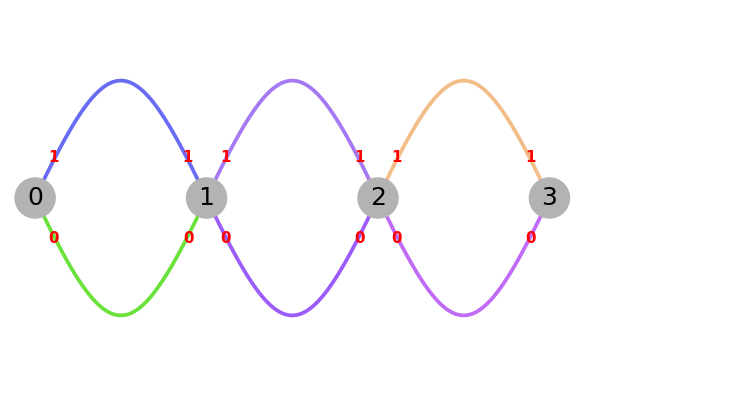

In [3]:
oruga_n3 = FramedDiGraph([
    [0, 1, 2, 3],
    [(0, 1, (0, 0)), (0, 1, (1, 1)),
     (1, 2, (0, 0)), (1, 2, (1, 1)),
     (2, 3, (0, 0)), (2, 3, (1, 1))]
], multiedges=True)

print('vertices:', oruga_n3.vertices(sort=True))
print('edges   :', oruga_n3.edges(sort=True))
print('|E|-|V|+2 =', oruga_n3.num_edges() - oruga_n3.num_verts() + 2,
      '  (saturated clique size)')
oruga_n3.draw_framed_digraph(y_spread=1, fontsize=10, dpi=180)

## Task C — Routes, coherence, and saturated cliques

* `G.routes()` returns every source–to–sink `Route` of $G$.
* Two routes are **coherent** if their relative framing order is preserved on every shared subpath
  (`P.is_coherent(Q)`).
* A `Clique` is a tuple of pairwise coherent routes; it is **saturated** when it contains exactly
  $|E| - |V| + 2$ routes.

List all routes of $\mathrm{oru}(3)$, then enumerate its saturated cliques by brute force.

In [4]:
all_routes = oruga_n3.routes()
print(f'{len(all_routes)} routes on oruga_n3:')
for r in all_routes:
    print('  ', r)

8 routes on oruga_n3:
   Route((0, 3), ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (0, 0))))
   Route((0, 3), ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (1, 1))))
   Route((0, 3), ((0, 1, (0, 0)), (1, 2, (1, 1)), (2, 3, (0, 0))))
   Route((0, 3), ((0, 1, (0, 0)), (1, 2, (1, 1)), (2, 3, (1, 1))))
   Route((0, 3), ((0, 1, (1, 1)), (1, 2, (0, 0)), (2, 3, (0, 0))))
   Route((0, 3), ((0, 1, (1, 1)), (1, 2, (0, 0)), (2, 3, (1, 1))))
   Route((0, 3), ((0, 1, (1, 1)), (1, 2, (1, 1)), (2, 3, (0, 0))))
   Route((0, 3), ((0, 1, (1, 1)), (1, 2, (1, 1)), (2, 3, (1, 1))))


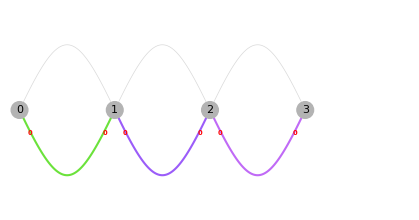

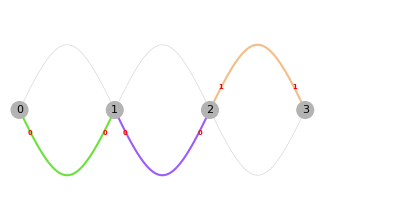

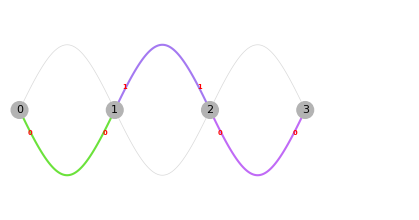

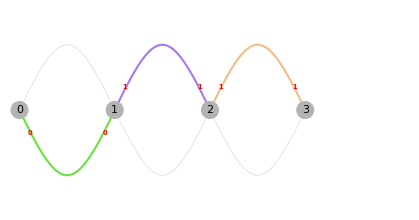

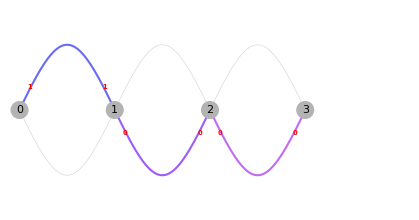

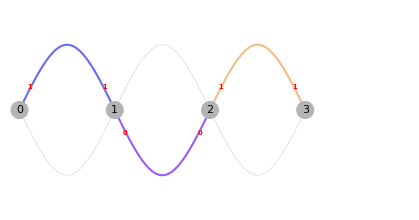

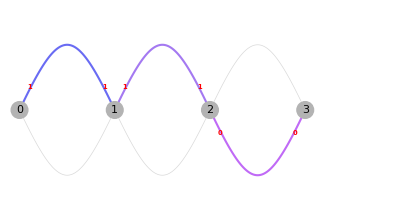

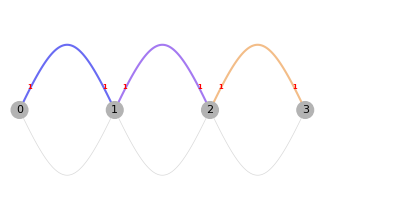

In [5]:
for r in all_routes:
    r.draw()

In [5]:
def saturated_cliques(G):
    routes = G.routes()
    target = G.num_edges() - G.num_verts() + 2
    out = []
    for combo in Combinations(routes, target):
        if all(p.is_coherent(q) for p, q in combinations(combo, 2)):
            out.append(Clique(G, list(combo)))
    return out

for i, C in enumerate(saturated_cliques(oruga_n3)):
    print(f'C_{i}: saturated={C.saturated},  routes:')
    for r in C:
        print('     ', r)

C_0: saturated=True,  routes:
      Route((0, 3), ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (0, 0))))
      Route((0, 3), ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (1, 1))))
      Route((0, 3), ((0, 1, (0, 0)), (1, 2, (1, 1)), (2, 3, (1, 1))))
      Route((0, 3), ((0, 1, (1, 1)), (1, 2, (1, 1)), (2, 3, (1, 1))))
C_1: saturated=True,  routes:
      Route((0, 3), ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (0, 0))))
      Route((0, 3), ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (1, 1))))
      Route((0, 3), ((0, 1, (1, 1)), (1, 2, (0, 0)), (2, 3, (1, 1))))
      Route((0, 3), ((0, 1, (1, 1)), (1, 2, (1, 1)), (2, 3, (1, 1))))
C_2: saturated=True,  routes:
      Route((0, 3), ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (0, 0))))
      Route((0, 3), ((0, 1, (0, 0)), (1, 2, (1, 1)), (2, 3, (0, 0))))
      Route((0, 3), ((0, 1, (0, 0)), (1, 2, (1, 1)), (2, 3, (1, 1))))
      Route((0, 3), ((0, 1, (1, 1)), (1, 2, (1, 1)), (2, 3, (1, 1))))
C_3: saturated=True,  routes:
      Route((0, 3), ((0, 1, (0, 0)), (1,

## Task D — `FramedIntegerFlows`, the weak order, and permutation flows

`FramedIntegerFlows(G)` enumerates all integer flows compatible with the canonical netflow.  Each
element is a `FramedIntegerFlow`, which exposes:

* `.to_clique()` — the saturated `Clique` of routes the flow encodes;
* `.to_permutation_flow()` — the associated `PermutationFlow`, whose `.final_summary()` gives the permutation read off at the sink;
* `.S_to_Z()` and `.Z_to_S()` — ascent and descent statistics on the weak order.

The collection has `.get_weak_order()` (a `Poset`) or `.get_weak_order(digraph=True)` (a `Digraph`), and `.Eulerian_polynomial()`.

cardinality           : 6
flow polytope volume  : 6
h*-vector             : [1, 4, 1]
Eulerian polynomial   : t^2 + 4*t + 1
  pi_0: final_summary = [0, 2, 1, 3]
  pi_1: final_summary = [0, 2, 3, 1]
  pi_2: final_summary = [0, 3, 2, 1]
  pi_3: final_summary = [0, 1, 2, 3]
  pi_4: final_summary = [0, 1, 3, 2]
  pi_5: final_summary = [0, 3, 1, 2]


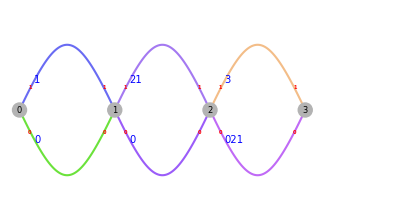

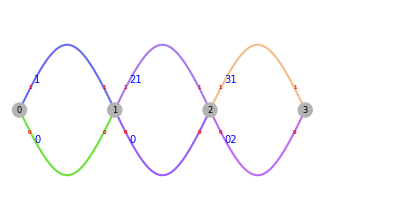

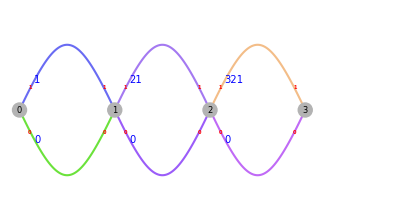

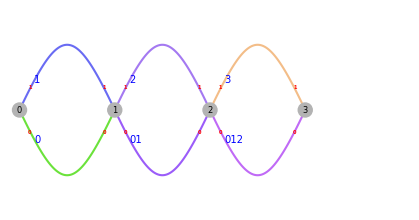

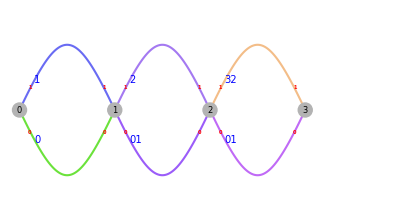

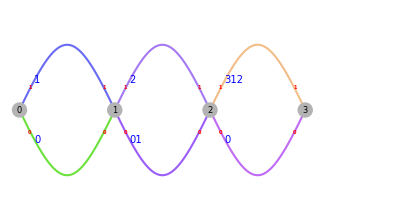

In [26]:
IF = FramedIntegerFlows(oruga_n3)
print('cardinality           :', IF.cardinality())
print('flow polytope volume  :', IF.flow_polytope_volume())
print('h*-vector             :', IF.h_star_vector())
print('Eulerian polynomial   :', IF.Eulerian_polynomial())

for i, f in enumerate(IF):
    pf = f.to_permutation_flow()
    pf.draw_framed_digraph()
    print(f'  pi_{i}: final_summary = {pf.final_summary()}')

weak order is a lattice? True


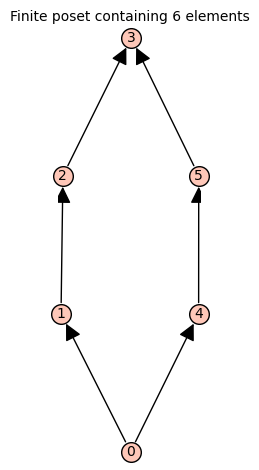

In [16]:
P_wo, elem = IF.get_weak_order()
print('weak order is a lattice?', P_wo.is_lattice())
P_wo

(<Figure size 2121.31x2121.31 with 1 Axes>,
 <Axes: >,
 {(1, 2, (1, 1)): 0, (2, 3, (1, 1)): 1})

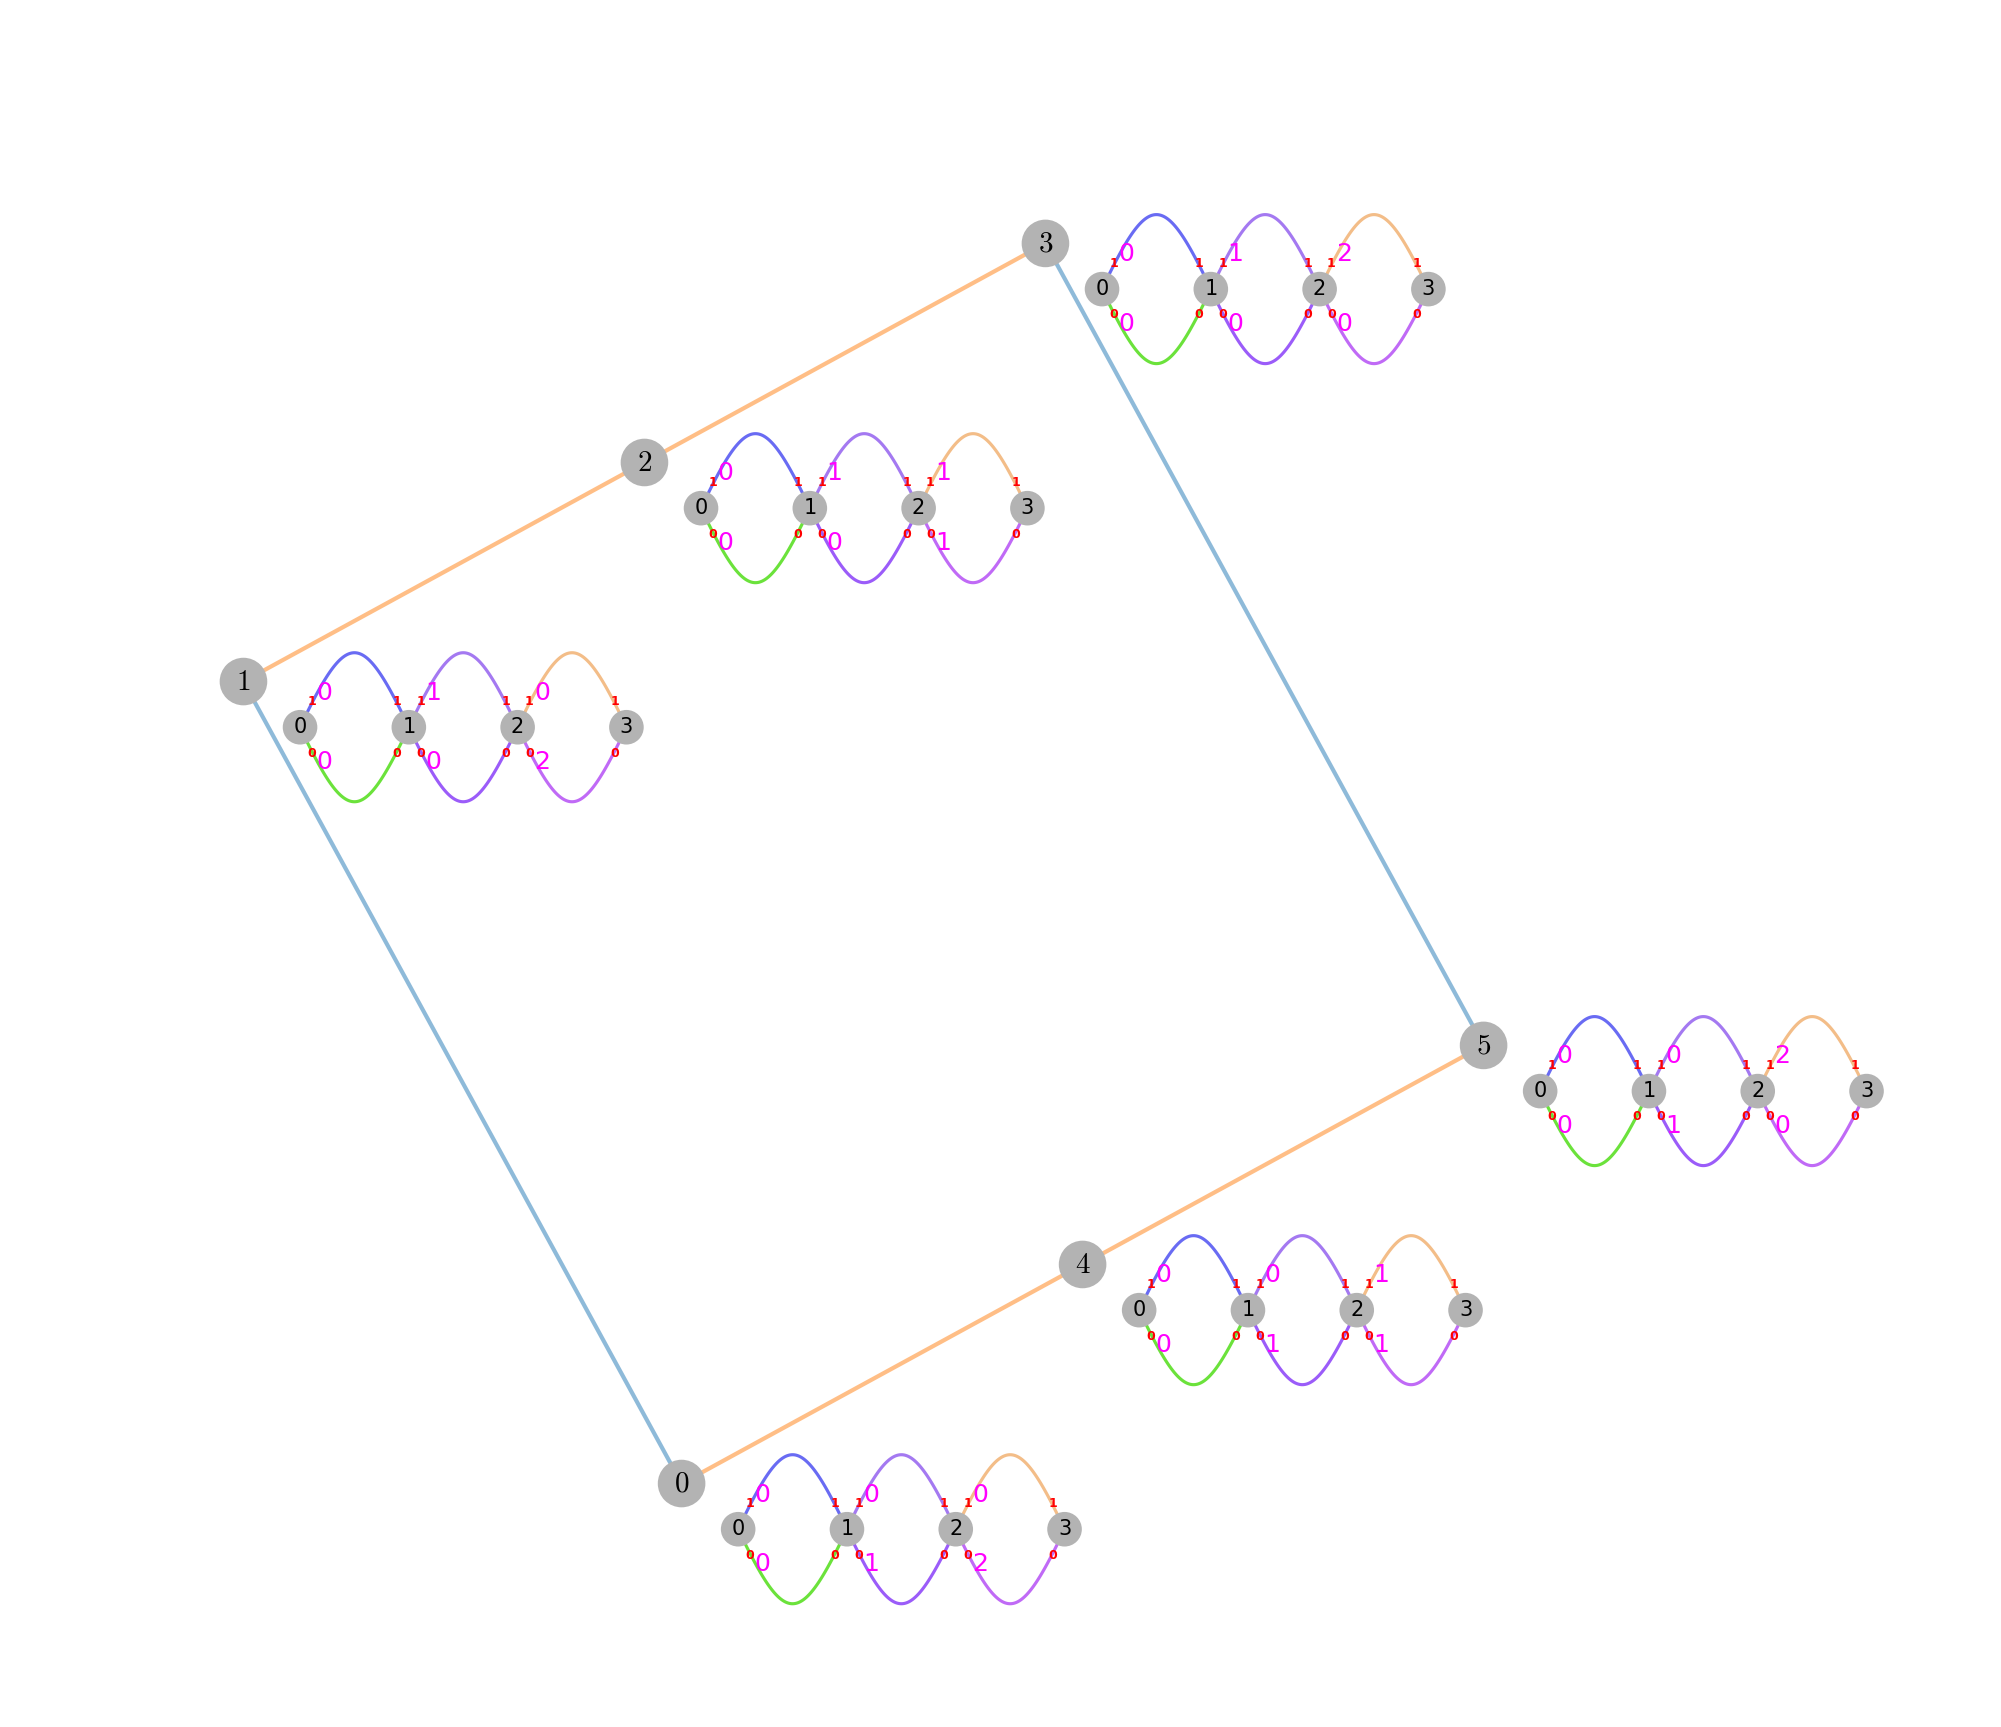

In [25]:
IF.draw_weak_order(
    scalar_spread=3, tilt=0.5,
    integer_flow='flow', clique=False,
    inset_factor=0.5, inset_fontsize=10, dpi=150, fontsize=14,
)

(<Figure size 2121.31x2121.31 with 1 Axes>,
 <Axes: >,
 {(1, 2, (1, 1)): 0, (2, 3, (1, 1)): 1})

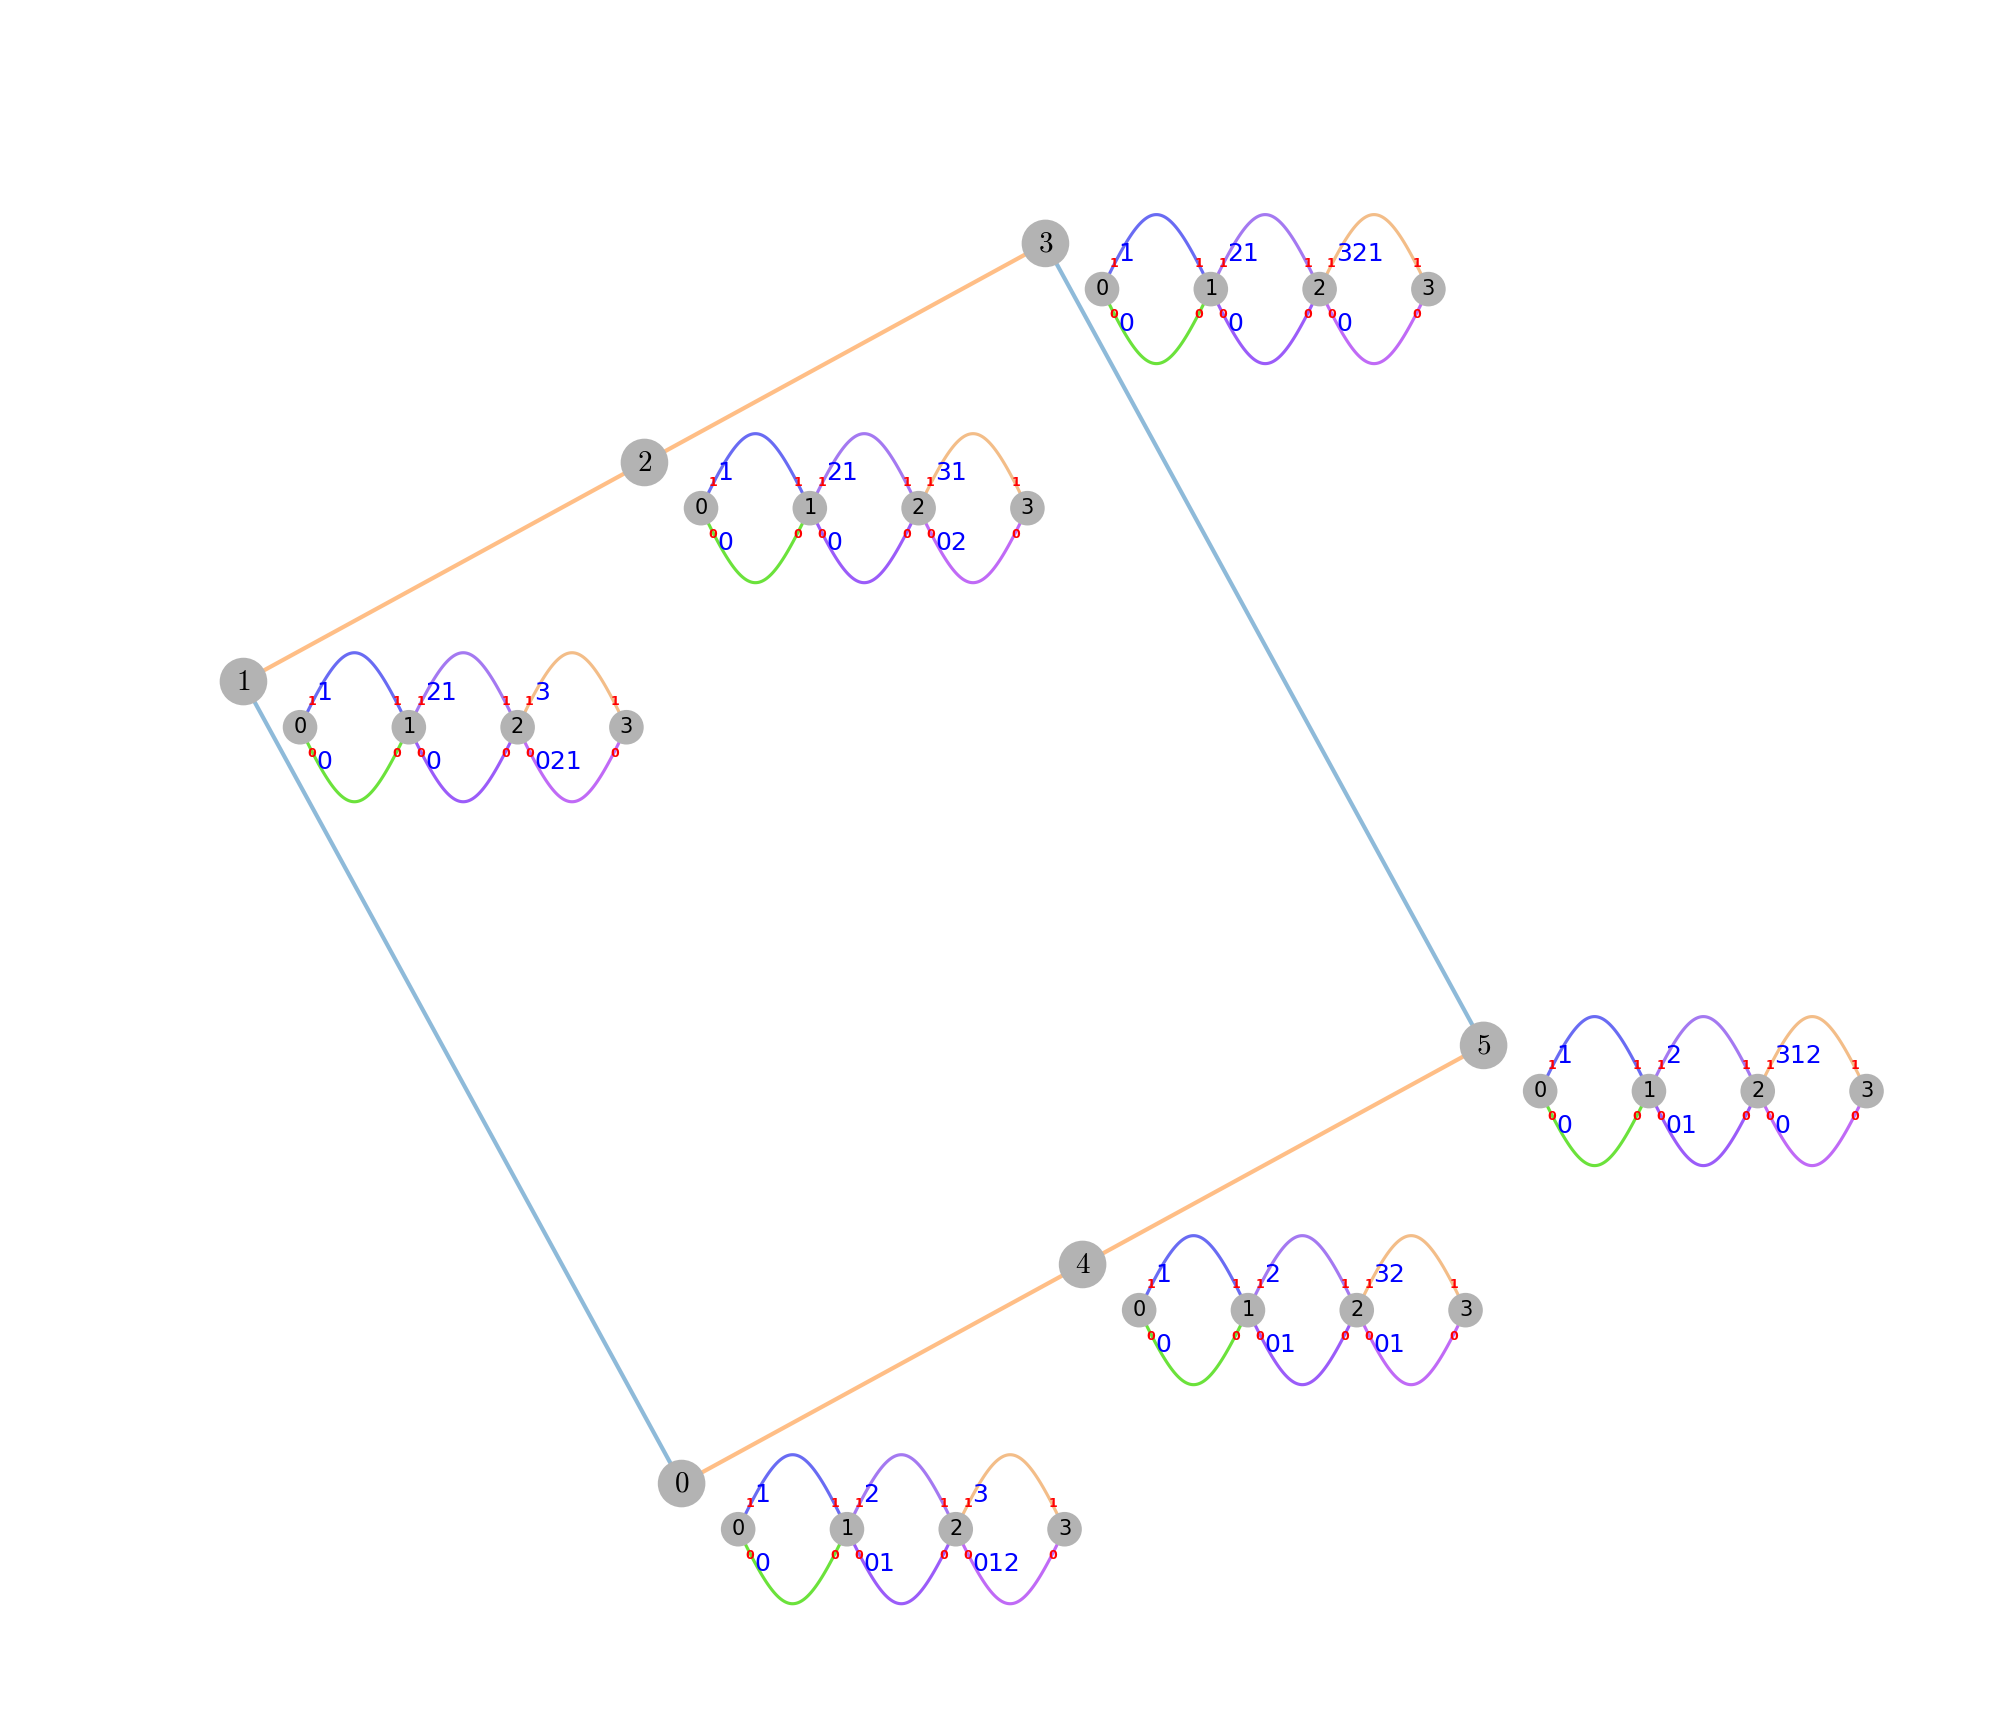

In [24]:
IF.draw_weak_order(
    scalar_spread=3, tilt=0.5,
    integer_flow='permutation', clique=False,
    inset_factor=0.5, inset_fontsize=10, dpi=150, fontsize=14,
)

(<Figure size 2121.31x2121.31 with 1 Axes>,
 <Axes: >,
 {(1, 2, (1, 1)): 0, (2, 3, (1, 1)): 1})

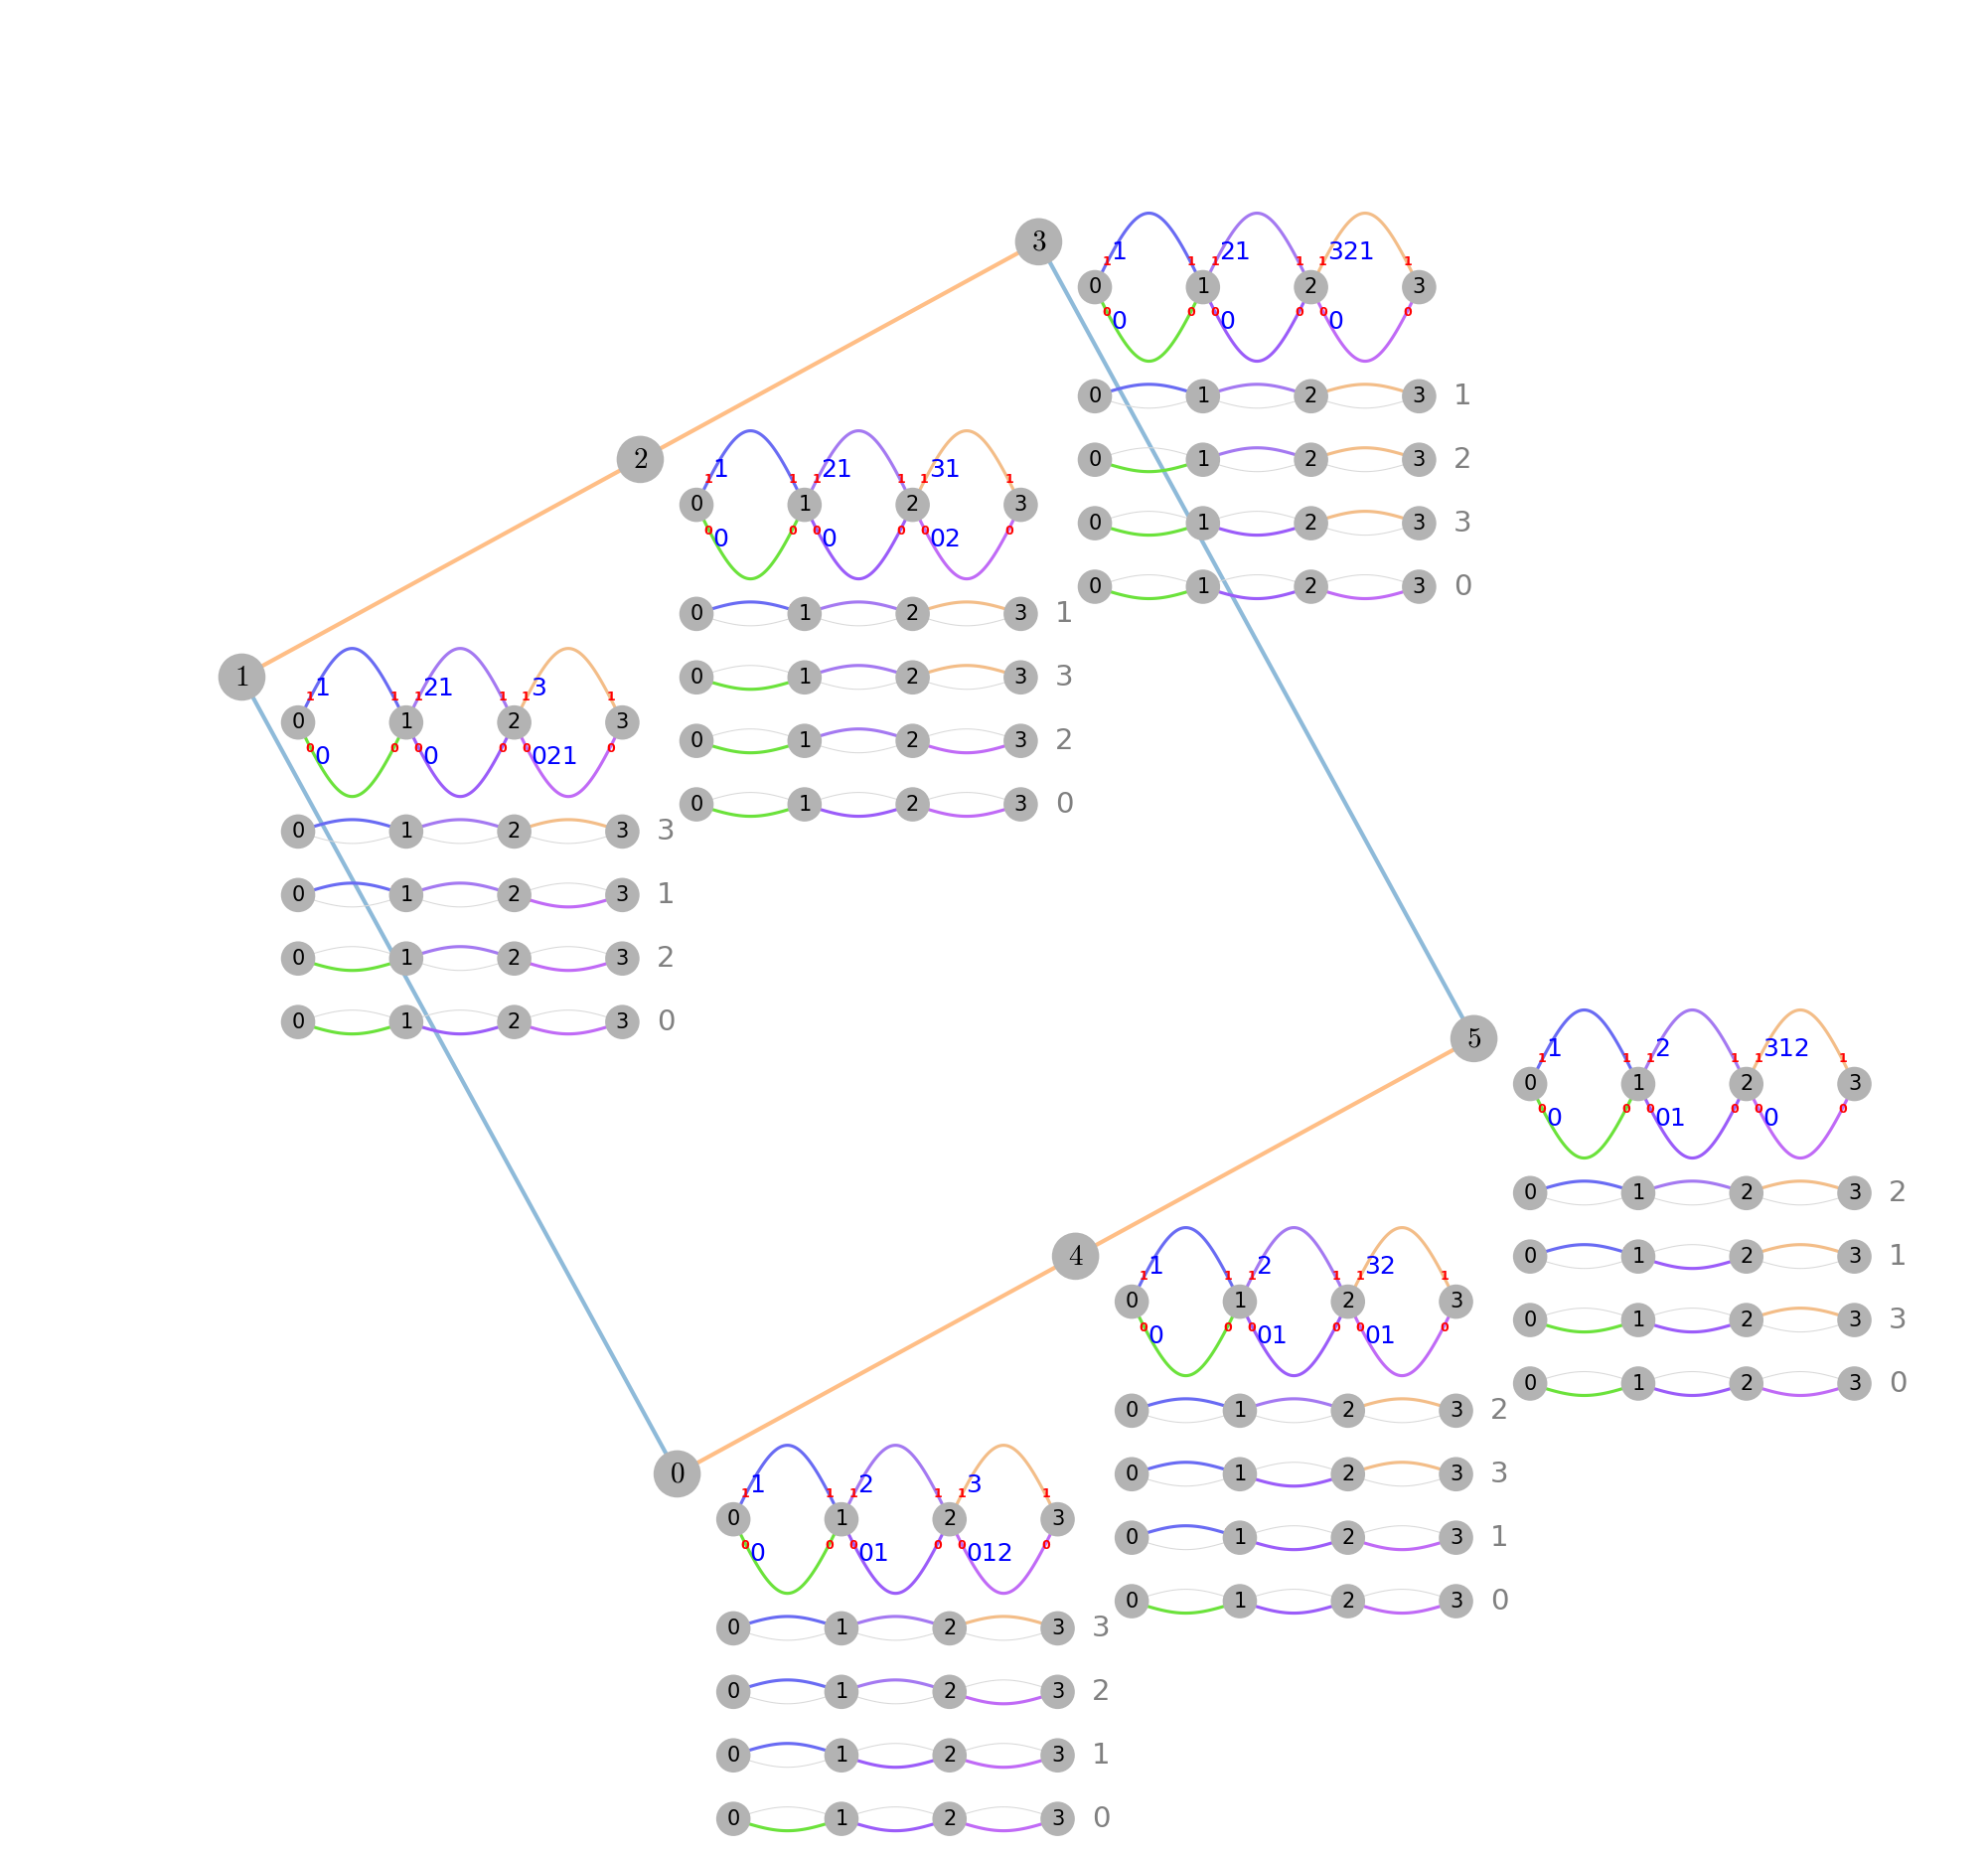

In [27]:
IF.draw_weak_order(
    scalar_spread=3, tilt=0.5,
    integer_flow='permutation', clique=True,
    inset_factor=0.5, inset_fontsize=10, dpi=150, fontsize=14,
)

## Task F — Build $\mathrm{car}(3) = \mathrm{car}(1,1,1)$ with two framings (Worksheet Problem 1)

From the worksheet picture: $G$ has $4$ vertices and $7$ edges — two parallel edges $0 \to 1$,
two parallel edges $2 \to 3$, the straight middle edge $1 \to 2$, and the long arcs $0 \to 2$ and
$1 \to 3$.  

car(3) with F_l
   (0, 1, (0, 0))
   (0, 1, (1, 1))
   (0, 2, (2, 1))
   (1, 2, (0, 0))
   (1, 3, (1, 2))
   (2, 3, (0, 0))
   (2, 3, (1, 1))

car(3) with F_p
   (0, 1, (0, 0))
   (0, 1, (1, 1))
   (0, 2, (2, 1))
   (1, 2, (1, 0))
   (1, 3, (0, 0))
   (2, 3, (0, 1))
   (2, 3, (1, 2))



(<Figure size 600x300 with 1 Axes>, <Axes: >)

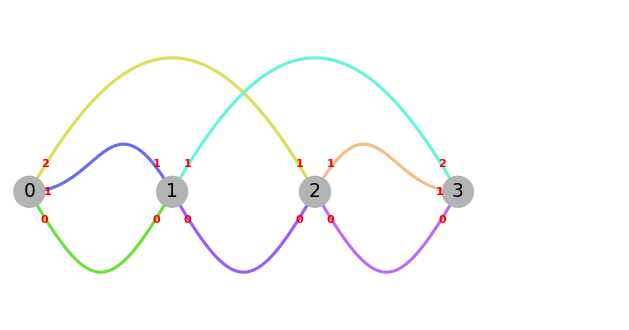

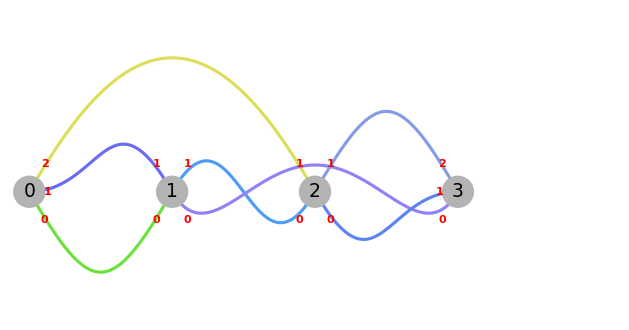

In [29]:
# --- Framing F_l (the "length" framing) ---
G_car_l = FramedDiGraph([
    [0, 1, 2, 3],
    [(0, 1, (0, 0)), (0, 1, (1, 1)),
     (0, 2, (2, 1)),
     (1, 2, (0, 0)),
     (1, 3, (1, 2)),
     (2, 3, (0, 0)), (2, 3, (1, 1))]
], multiedges=True)

# --- Framing F_p (a different planar framing) ---
G_car_p = FramedDiGraph([
    [0, 1, 2, 3],
    [(0, 1, (0, 0)), (0, 1, (1, 1)),
     (0, 2, (2, 1)),
     (1, 2, (1, 0)),
     (1, 3, (0, 0)),
     (2, 3, (0, 1)), (2, 3, (1, 2))]
], multiedges=True)

for G, name in [(G_car_l, 'car(3) with F_l'), (G_car_p, 'car(3) with F_p')]:
    print(name)
    for e in sorted(G.edges(sort=False)):
        print('  ', e)
    print()

G_car_l.show(y_spread=1, fontsize=9, dpi=150)
G_car_p.show(y_spread=1, fontsize=9, dpi=150)

## Task G — Saturated cliques of $\mathrm{car}(3)$ for both framings (Problem 1, parts (a)–(b))

Use `saturated_cliques(G)` from Task C.  The worksheet says you should see $s = 5$ for each
framing.  Then, for every cover $\mathcal{C} \lessdot \mathcal{C}'$, identify the descending route
$P$ and the ascending route $Q$ — these are precisely the pairs in which $\mathcal{C}$ and
$\mathcal{C}'$ differ by a single route.

F_l: 5 saturated cliques
F_p: 5 saturated cliques

F_l, C_0:
   Route((0, 3), ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (0, 0))))
   Route((0, 3), ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (1, 1))))
   Route((0, 3), ((0, 1, (0, 0)), (1, 3, (1, 2))))
   Route((0, 3), ((0, 1, (1, 1)), (1, 3, (1, 2))))
   Route((0, 3), ((0, 2, (2, 1)), (2, 3, (1, 1))))

F_l, C_1:
   Route((0, 3), ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (0, 0))))
   Route((0, 3), ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (1, 1))))
   Route((0, 3), ((0, 1, (1, 1)), (1, 2, (0, 0)), (2, 3, (1, 1))))
   Route((0, 3), ((0, 1, (1, 1)), (1, 3, (1, 2))))
   Route((0, 3), ((0, 2, (2, 1)), (2, 3, (1, 1))))

F_l, C_2:
   Route((0, 3), ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (0, 0))))
   Route((0, 3), ((0, 1, (0, 0)), (1, 3, (1, 2))))
   Route((0, 3), ((0, 1, (1, 1)), (1, 3, (1, 2))))
   Route((0, 3), ((0, 2, (2, 1)), (2, 3, (0, 0))))
   Route((0, 3), ((0, 2, (2, 1)), (2, 3, (1, 1))))

F_l, C_3:
   Route((0, 3), ((0, 1, (0, 0)), (1, 2, (0, 

(<Figure size 600x300 with 1 Axes>, <Axes: >)

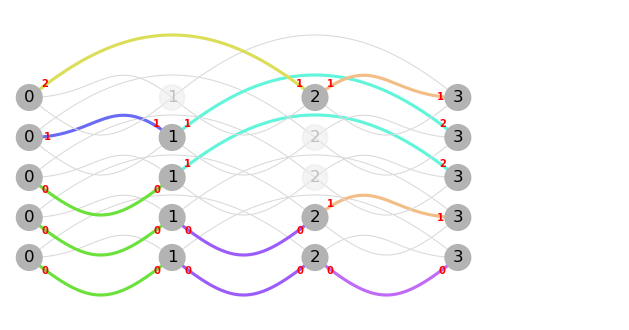

In [30]:
C_l = saturated_cliques(G_car_l)
C_p = saturated_cliques(G_car_p)
print(f'F_l: {len(C_l)} saturated cliques')
print(f'F_p: {len(C_p)} saturated cliques')

for k, C in enumerate(C_l):
    print(f'\nF_l, C_{k}:')
    for r in C:
        print('  ', r)

# Visualize one of the cliques (try the others too).
C_l[0].draw(vertical_stretch=0.2, y_spread=1, dpi=150, fontsize=8)

In [32]:
def clique_set(C):
    return frozenset(tuple(r.edges()) for r in C)

def adjacent_cliques(cliques):
    """Return pairs (i, j, P, Q) of clique indices that differ in exactly one route."""
    sets = [clique_set(C) for C in cliques]
    pairs = []
    for i in range(len(cliques)):
        for j in range(i + 1, len(cliques)):
            di, dj = sets[i] - sets[j], sets[j] - sets[i]
            if len(di) == 1 and len(dj) == 1:
                pairs.append((i, j, list(di)[0], list(dj)[0]))
    return pairs

for name, cliques in [('F_l', C_l), ('F_p', C_p)]:
    print(f'--- {name}: cover candidates (unoriented) ---')
    for i, j, P, Q in adjacent_cliques(cliques):
        print(f'  C_{i} ~ C_{j}  swap {P}  <->  {Q}')
    print()

--- F_l: cover candidates (unoriented) ---
  C_0 ~ C_1  swap ((0, 1, (0, 0)), (1, 3, (1, 2)))  <->  ((0, 1, (1, 1)), (1, 2, (0, 0)), (2, 3, (1, 1)))
  C_0 ~ C_2  swap ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (1, 1)))  <->  ((0, 2, (2, 1)), (2, 3, (0, 0)))
  C_1 ~ C_3  swap ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (1, 1)))  <->  ((0, 1, (1, 1)), (1, 2, (0, 0)), (2, 3, (0, 0)))
  C_2 ~ C_4  swap ((0, 1, (0, 0)), (1, 3, (1, 2)))  <->  ((0, 1, (1, 1)), (1, 2, (0, 0)), (2, 3, (0, 0)))
  C_3 ~ C_4  swap ((0, 1, (1, 1)), (1, 2, (0, 0)), (2, 3, (1, 1)))  <->  ((0, 2, (2, 1)), (2, 3, (0, 0)))

--- F_p: cover candidates (unoriented) ---
  C_0 ~ C_1  swap ((0, 1, (0, 0)), (1, 2, (1, 0)), (2, 3, (1, 2)))  <->  ((0, 1, (1, 1)), (1, 2, (1, 0)), (2, 3, (0, 1)))
  C_1 ~ C_2  swap ((0, 1, (1, 1)), (1, 2, (1, 0)), (2, 3, (1, 2)))  <->  ((0, 2, (2, 1)), (2, 3, (0, 1)))
  C_1 ~ C_3  swap ((0, 1, (0, 0)), (1, 2, (1, 0)), (2, 3, (0, 1)))  <->  ((0, 1, (1, 1)), (1, 3, (0, 0)))
  C_2 ~ C_4  swap ((0, 1, (0, 0))

## Task H — Hasse diagram of the framing order on $\mathrm{car}(3)$ (Problem 1, part (c))

The framing order is exactly the weak order on saturated cliques (= weak order on saturated
permutation flows), provided by `FramedIntegerFlows`.  Verify it is a lattice for both framings.

F_l: lattice? True   cardinality: 5
F_p: lattice? True   cardinality: 5


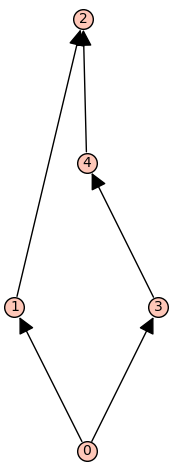

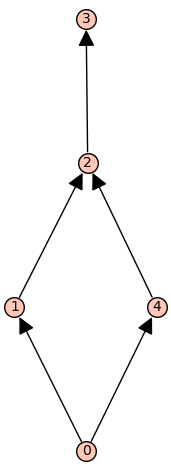

(<Figure size 1726.4x2121.31 with 1 Axes>,
 <Axes: >,
 {(1, 2, (1, 0)): 0, (2, 3, (1, 2)): 1})

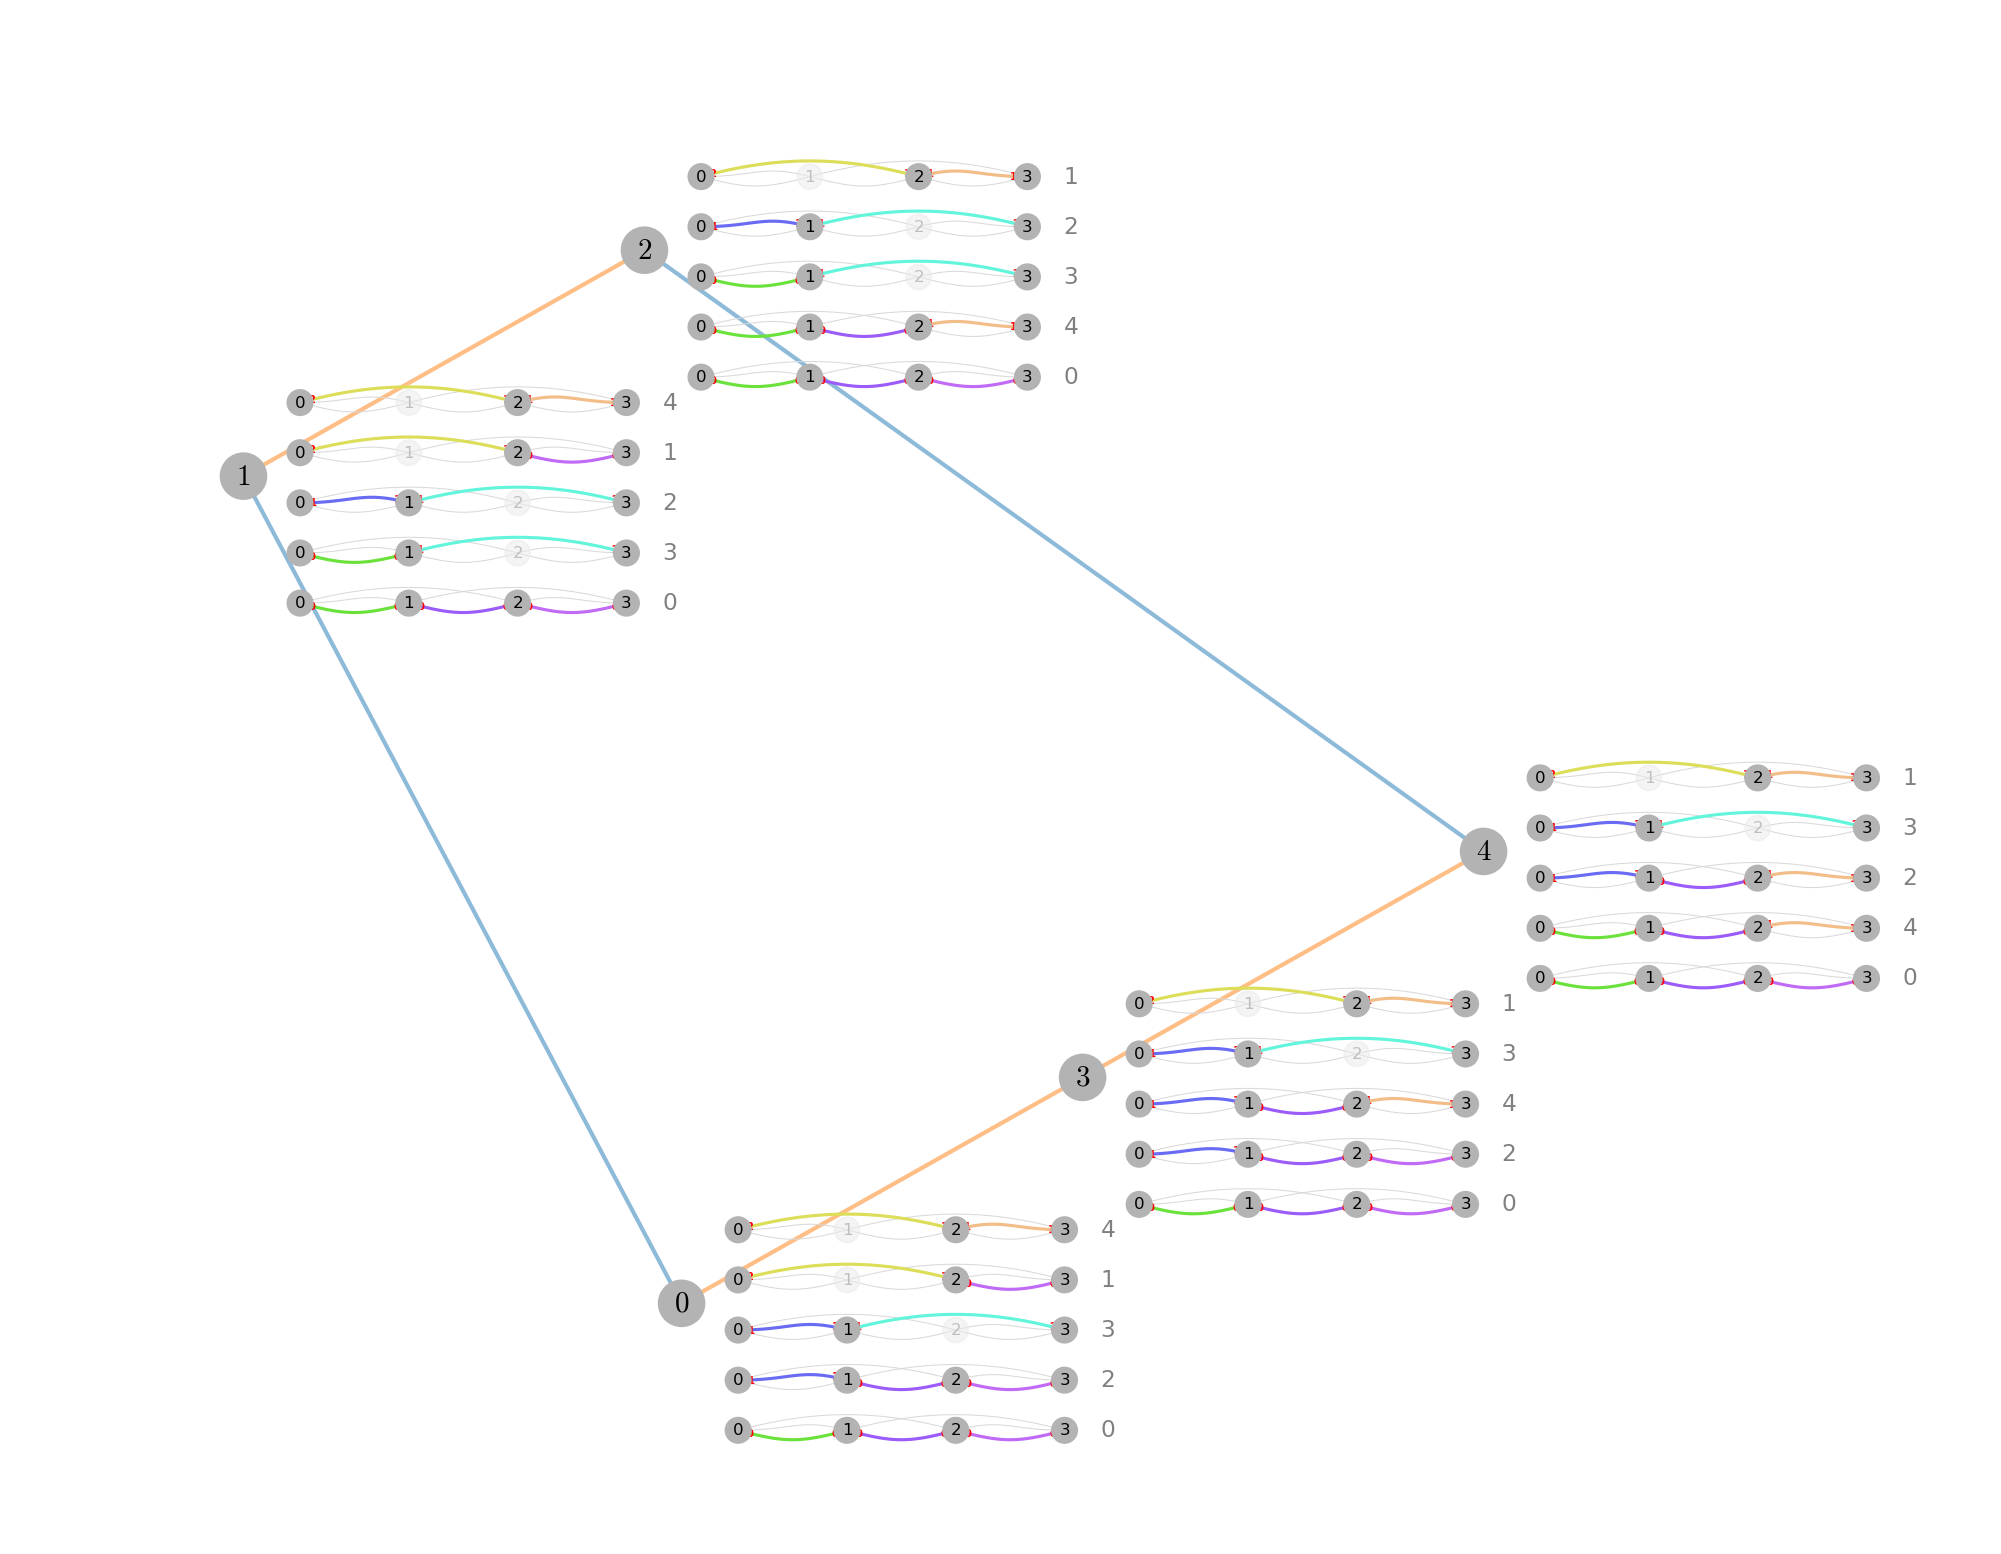

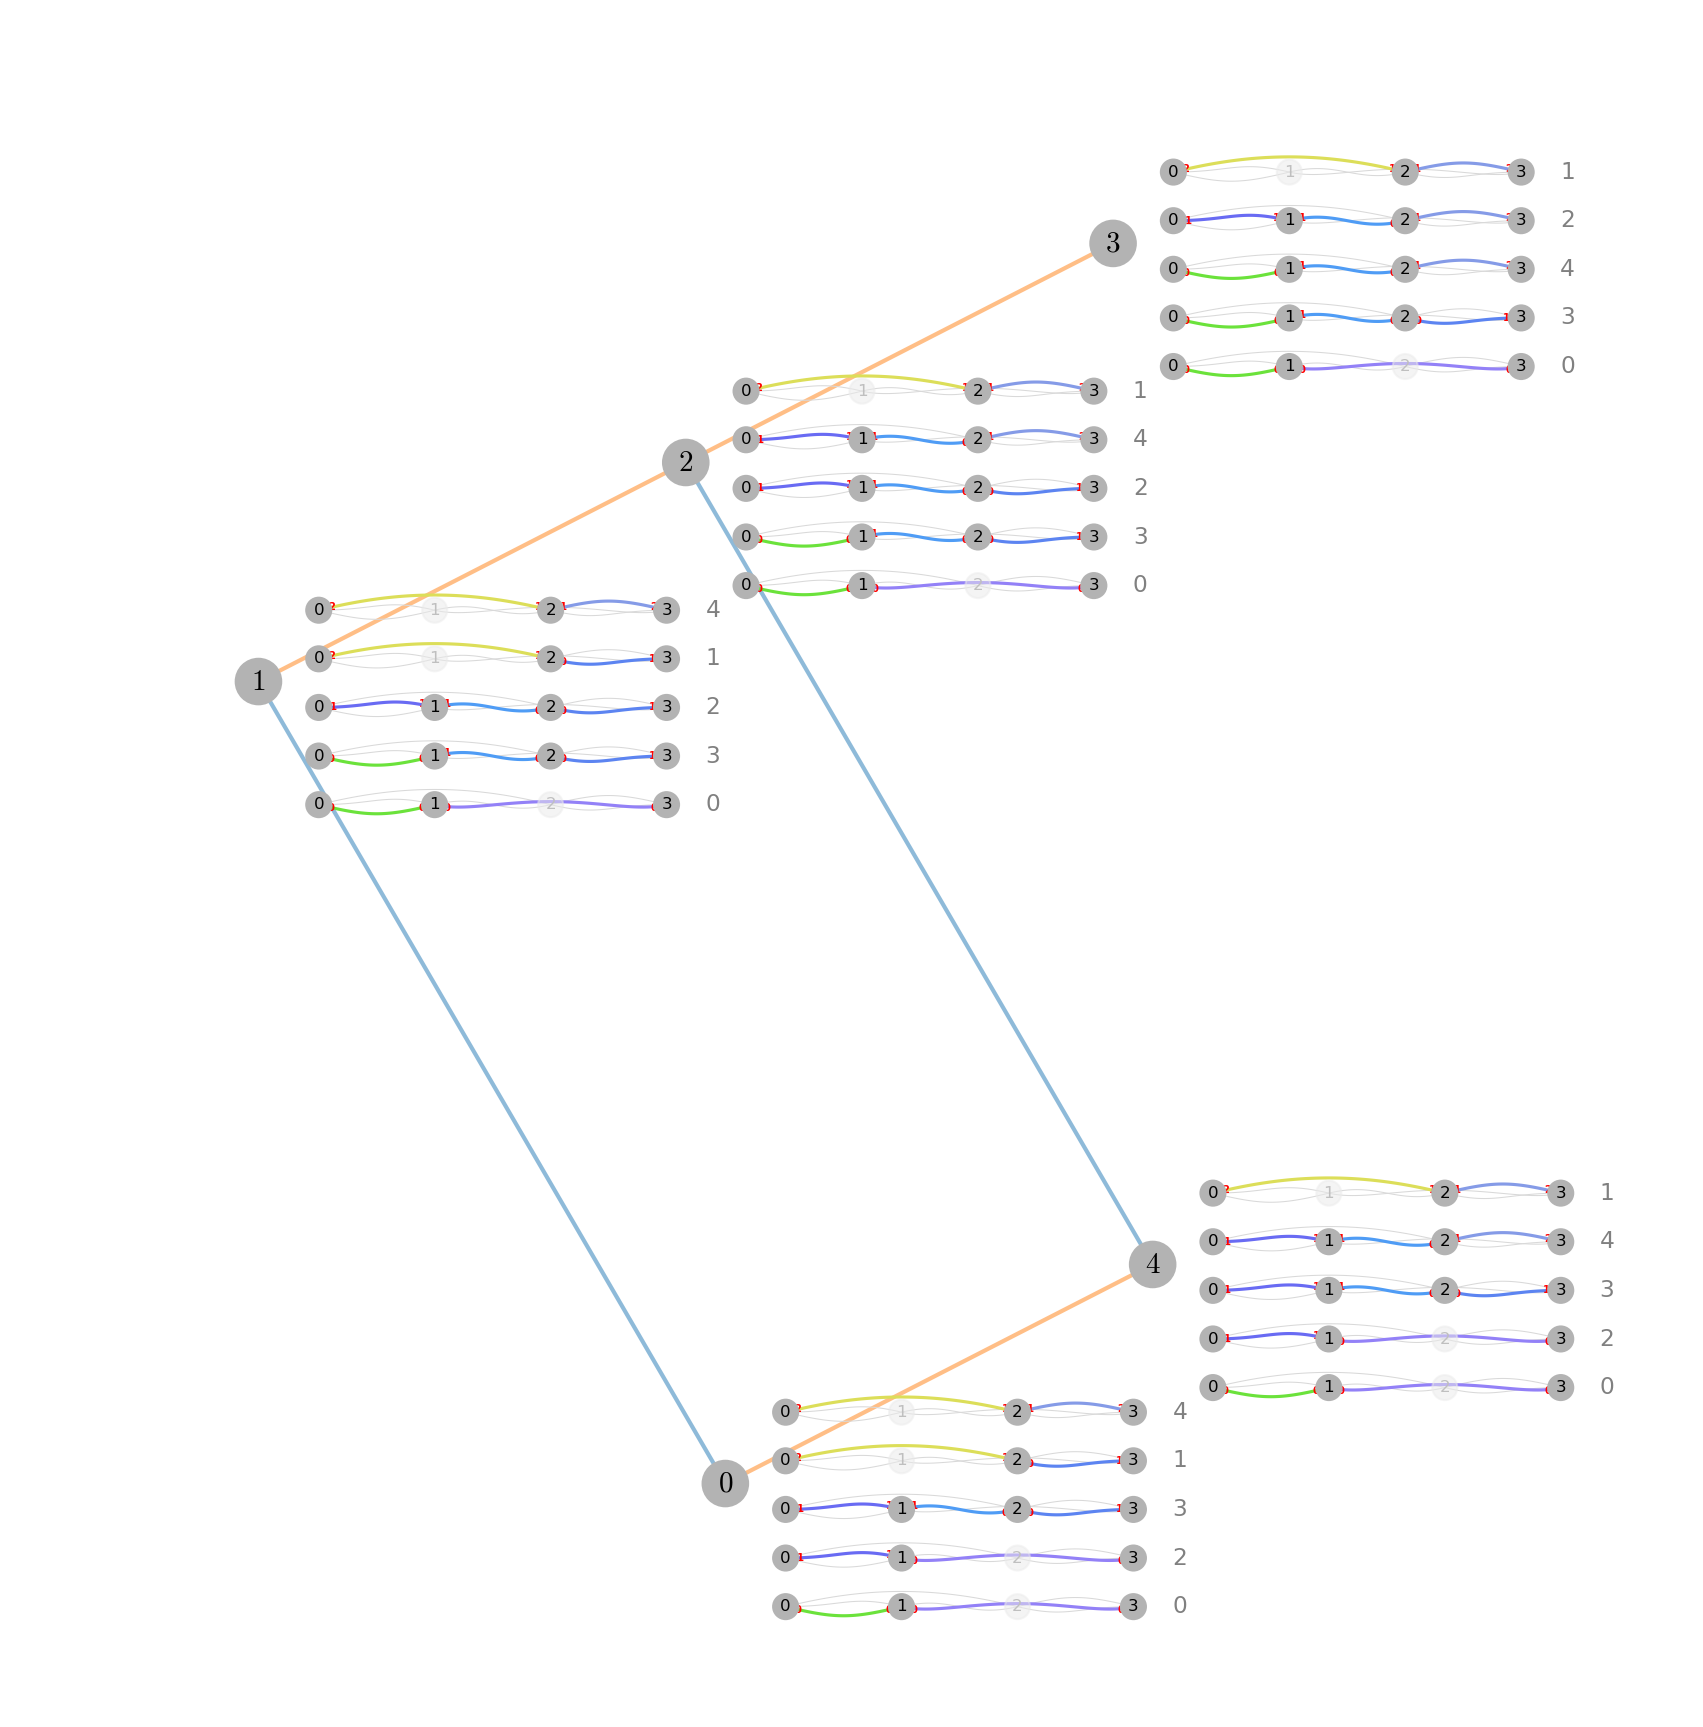

In [34]:
IF_l = FramedIntegerFlows(G_car_l)
IF_p = FramedIntegerFlows(G_car_p)

P_l, _ = IF_l.get_weak_order()
P_p, _ = IF_p.get_weak_order()
print('F_l: lattice?', P_l.is_lattice(), '  cardinality:', P_l.cardinality())
print('F_p: lattice?', P_p.is_lattice(), '  cardinality:', P_p.cardinality())

P_l.show()
P_p.show()

IF_l.draw_weak_order(
    scalar_spread=3, tilt=0.5,
    integer_flow=None, clique=True,
    inset_factor=0.5, inset_fontsize=8, dpi=150, fontsize=14,
)
IF_p.draw_weak_order(
    scalar_spread=3, tilt=0.5,
    integer_flow=None, clique=True,
    inset_factor=0.5, inset_fontsize=8, dpi=150, fontsize=14,
)

## Task I — Saturated permutation flows, final summaries, and lattice points (Problem 1, parts (d)–(f))

* (d) Enumerate the saturated permutation flows $\mathrm{SatPF}(G, F)$ via `FramedIntegerFlows`.
* (e) For each $\pi \in \mathrm{SatPF}(G, F)$, compute the final summary at the sink with
  `f.to_permutation_flow().final_summary()`.
* (f) Verify that $(|\pi(e)| - 1)_{e \in E}$ are exactly the lattice points of $\mathcal{F}_G(\vec d)$.

[0, 2, 1, 4, 3]
[0, 2, 4, 1, 3]
[0, 4, 2, 1, 3]
[0, 1, 4, 3, 2]
[0, 4, 1, 3, 2]


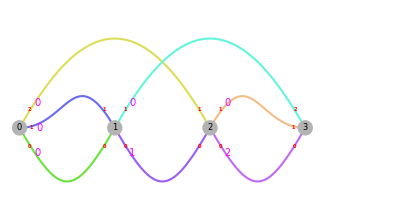

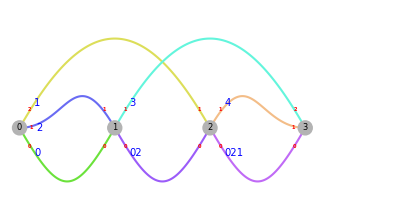

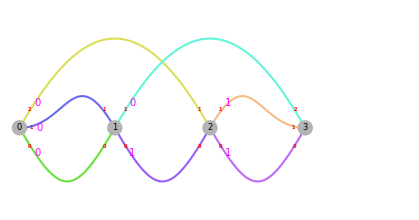

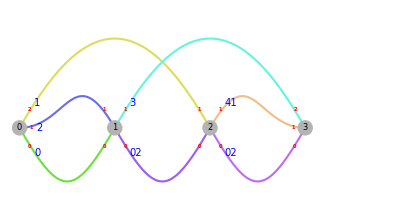

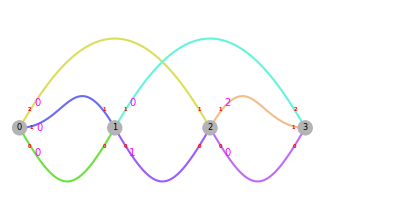

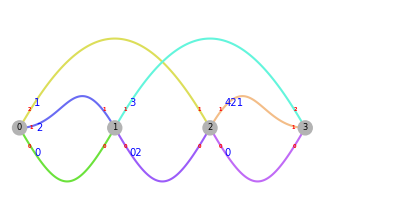

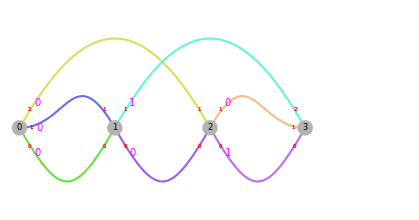

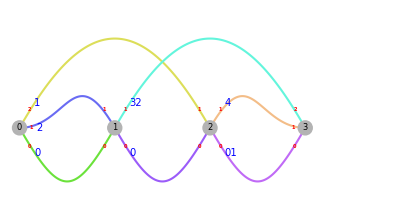

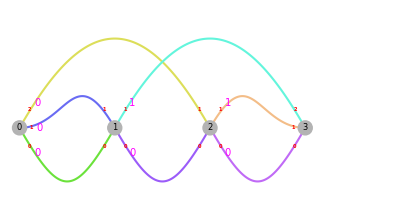

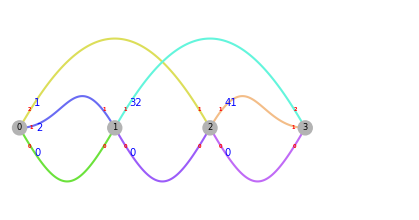

In [37]:
for f in IF_l:
    f.draw_framed_digraph(with_flow=True)
    pf=f.to_permutation_flow()
    pf.draw_framed_digraph(with_flow=True)
    print(pf.final_summary())

Route((0, 3), ((0, 1, (0, 0)), (1, 3, (0, 0))))
Route((0, 3), ((0, 1, (1, 1)), (1, 3, (0, 0))))
Route((0, 3), ((0, 1, (1, 1)), (1, 2, (1, 0)), (2, 3, (0, 1))))
Route((0, 3), ((0, 1, (1, 1)), (1, 2, (1, 0)), (2, 3, (1, 2))))
Route((0, 3), ((0, 2, (2, 1)), (2, 3, (1, 2))))


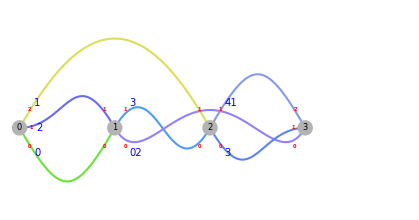

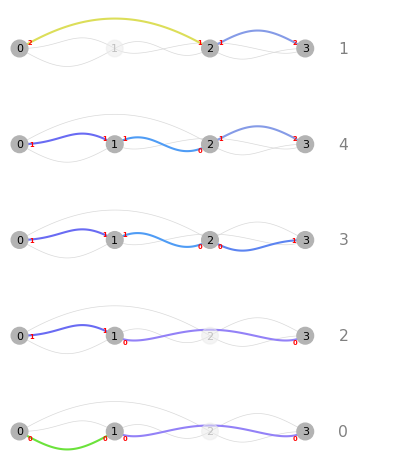

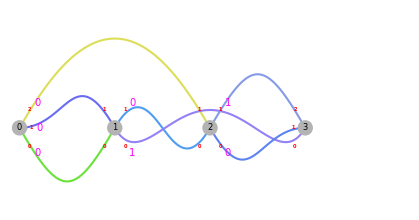

In [48]:
# Here there is some of the information corresponding to a single permutation flow
pf.draw_framed_digraph()
pf.draw_clique()
iflow = pf.to_framed_integer_flow()
iflow.draw_framed_digraph()
for route in pf.get_clique():
    print(route)

[0, 3, 2, 1, 4]
[0, 3, 2, 4, 1]
[0, 3, 4, 2, 1]
[0, 2, 3, 1, 4]
[0, 2, 3, 4, 1]


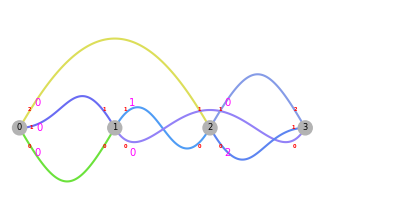

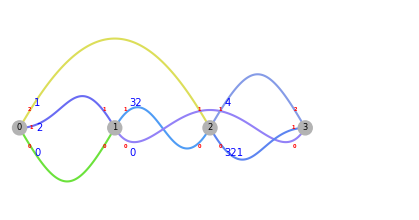

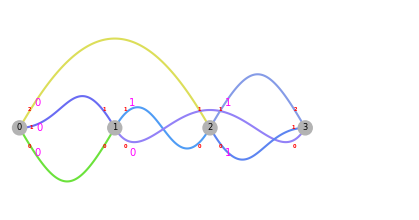

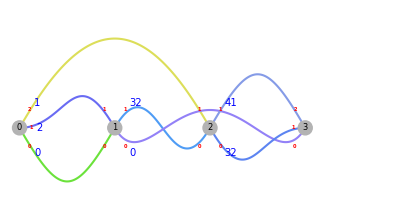

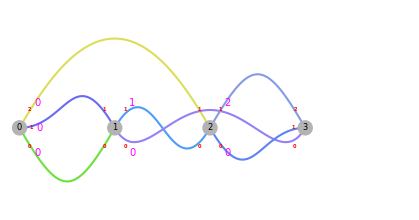

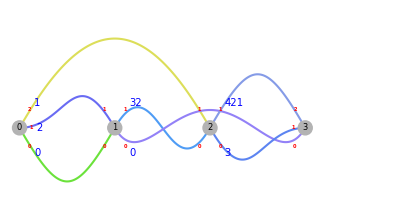

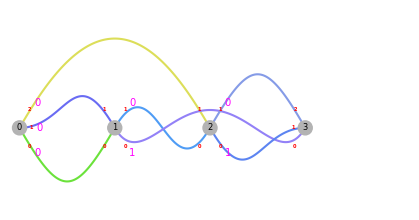

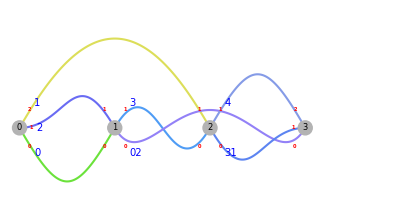

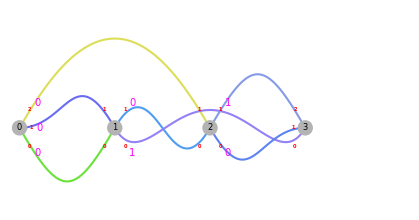

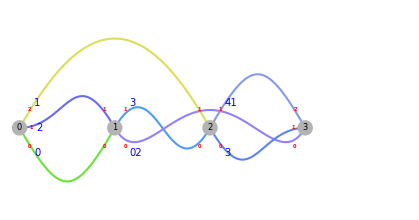

In [38]:
for f in IF_p:
    f.draw_framed_digraph(with_flow=True)
    pf=f.to_permutation_flow()
    pf.draw_framed_digraph(with_flow=True)
    print(pf.final_summary())

## Task J — Weak order on $\mathrm{SatPF}$ vs framing order on cliques (Problem 1, part (g))

Since `to_clique` is a bijection between $\mathrm{SatPF}$ and saturated cliques, the two posets
must be isomorphic.  Confirm cardinalities and lattice structure.

In [22]:
for name, IFx, cliques in [('F_l', IF_l, C_l), ('F_p', IF_p, C_p)]:
    P, _ = IFx.get_weak_order()
    print(f'{name}: |WO| = {P.cardinality()}, |Cliques| = {len(cliques)}, '
          f'lattice? {P.is_lattice()}')

F_l: |WO| = 5, |Cliques| = 5, lattice? True
F_p: |WO| = 5, |Cliques| = 5, lattice? True


## Task K — Descent statistic (Problem 1, parts (h)–(i))

* (h) $|\mathrm{SatPF}|$ for $\mathrm{car}(3)$ should equal a Catalan-style number.  Compare it
  with candidate sets and look for a pattern $\sigma$ avoided.
* (i) For each flow $f$, $\mathrm{des}(\pi) := S_{\to} Z(\pi) =$ `f.S_to_Z()`.  

In [26]:
for name, IFx in [('F_l', IF_l), ('F_p', IF_p)]:
    print(f'{name}:')
    for k, f in enumerate(IFx):
        rw = f.to_permutation_flow().final_summary()
        print(f'  pi_{k}: final_summary = {rw},  des = S_to_Z = {f.S_to_Z()},  '
              f'Z_to_S = {f.Z_to_S()}')

F_l:
  pi_0: final_summary = [0, 2, 1, 4, 3],  des = S_to_Z = 2,  Z_to_S = 0
  pi_1: final_summary = [0, 2, 4, 1, 3],  des = S_to_Z = 1,  Z_to_S = 1
  pi_2: final_summary = [0, 4, 2, 1, 3],  des = S_to_Z = 1,  Z_to_S = 1
  pi_3: final_summary = [0, 1, 4, 3, 2],  des = S_to_Z = 1,  Z_to_S = 1
  pi_4: final_summary = [0, 4, 1, 3, 2],  des = S_to_Z = 0,  Z_to_S = 2
F_p:
  pi_0: final_summary = [0, 3, 2, 1, 4],  des = S_to_Z = 1,  Z_to_S = 1
  pi_1: final_summary = [0, 3, 2, 4, 1],  des = S_to_Z = 1,  Z_to_S = 2
  pi_2: final_summary = [0, 3, 4, 2, 1],  des = S_to_Z = 0,  Z_to_S = 1
  pi_3: final_summary = [0, 2, 3, 1, 4],  des = S_to_Z = 2,  Z_to_S = 0
  pi_4: final_summary = [0, 2, 3, 4, 1],  des = S_to_Z = 1,  Z_to_S = 1


## Task L — The $(G, F)$-Eulerian polynomial of $\mathrm{car}(3)$ (Problem 1, part (j))

Compute $A_{(G, F_\ell)}(t)$ and $A_{(G, F_p)}(t)$; verify they are equal.  

In [29]:
A_l = IF_l.Eulerian_polynomial()
A_p = IF_p.Eulerian_polynomial()
print('A_(G, F_l)(t) =', A_l)
print('A_(G, F_p)(t) =', A_p)
print('equal?', A_l == A_p)

A_(G, F_l)(t) = t^2 + 3*t + 1
A_(G, F_p)(t) = t^2 + 3*t + 1
equal? True


## Task M — Repeat Problem 1 with $n=4$

In [ ]:
# Repeat all the steps of Problem 1 with n = 4

## Task N — Build $\mathrm{oru}(1, 2, 1)$ with the long arc and repeat the steps of Worksheet Problem 2

The underlying graph has $4$ vertices and a richer parallel structure: 2 edges $0 \to 1$, 3 edges
$1 \to 2$, 2 edges $2 \to 3$, plus the long arc $0 \to 2$ shown in the worksheet. 

edges:
   (0, 1, (0, 0))
   (0, 1, (1, 1))
   (0, 2, (2, 0))
   (1, 2, (0, 1))
   (1, 2, (1, 2))
   (1, 2, (2, 3))
   (2, 3, (0, 0))
   (2, 3, (1, 1))


(<Figure size 600x300 with 1 Axes>, <Axes: >)

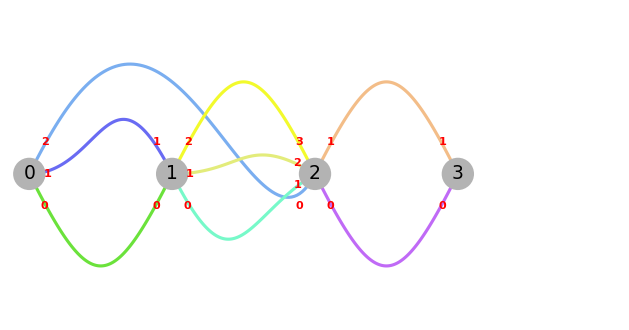

In [31]:
G_oru = FramedDiGraph([
    [0, 1, 2, 3],
    [(0, 1, (0, 0)), (0, 1, (1, 1)),
     (0, 2, (2, 0)),
     (1, 2, (0, 1)), (1, 2, (1, 2)), (1, 2, (2, 3)),
     (2, 3, (0, 0)), (2, 3, (1, 1))]
], multiedges=True)
print('edges:')
for e in sorted(G_oru.edges(sort=False)):
    print('  ', e)
G_oru.show(y_spread=1, fontsize=9, dpi=150)

# Run all the steps of Problem 2

---
### Going further

* Replace the framings of $\mathrm{car}(3)$ above by *other* framings and re-run the whole notebook.
* Try $\mathrm{car}(s)$ or $\mathrm{oru}(\mathbf s)$ for larger $\mathbf s$.
* Explore the lattices and $G$-Eulerian polynomials associated to other graphs.